# Import

In [1]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt


import seaborn as sns
from matplotlib.ticker import FuncFormatter

from sklearn.covariance import LedoitWolf

from matplotlib.gridspec import GridSpec
from scipy.optimize import minimize
from sklearn.covariance import LedoitWolf
#plt.style.use('seaborn-v0_8-darkgrid')
from dashboard import PortfolioDashboardVisualizer
import cvxpy as cp


import QuantLib as ql
from functools import lru_cache

from finance import get_calendar, COUNTRY_DEFAULT_FREQ_MAP


## Helpers QuantLib

In [2]:

@lru_cache(maxsize=None)
def _build_bond(issue_date, maturity_date, coupon_dec, freq, country_iso):
    """
    Construit et cache un FixedRateBond QuantLib + liste des cashflows (dates/amounts).
    Face = 100, settlementDays=0 (carry calculé "trade-date", simple et stable).
    """
    cal = get_calendar(country_iso)

    daycount = ql.ActualActual(ql.ActualActual.ISMA)

    issue_ql = ql.Date(issue_date.day, issue_date.month, issue_date.year)
    mat_ql   = ql.Date(maturity_date.day, maturity_date.month, maturity_date.year)

    frequency = {1: ql.Annual, 2: ql.Semiannual, 4: ql.Quarterly}.get(int(freq), ql.Semiannual)

    schedule = ql.Schedule(
        issue_ql,
        mat_ql,
        ql.Period(frequency),
        cal,
        ql.Following,
        ql.Following,
        ql.DateGeneration.Backward,
        False,
    )

    face = 100.0
    bond = ql.FixedRateBond(0, face, schedule, [float(coupon_dec)], daycount)

    cfs = [(cf.date(), float(cf.amount())) for cf in bond.cashflows() if isinstance(cf, ql.Coupon)]
    cfs.sort(key=lambda x: x[0])

    return bond, cfs


def _compute_carry_for_isin(df_isin):
    """
    carry journalier (unité "return" / notional) = (Δaccrued + coupons payés) / 100
    sur l'intervalle (t_{k-1}, t_k].
    """
    df = df_isin.sort_values("time_stamp").copy()

    # Si metadata manquante, on retourne sur l'ancienne approximation
    if (df["issue_date"].isna().all() or df["maturity_date"].isna().all() or df["coupon_dec"].isna().all()):
        df["pnl_carry"] = (df["price"] / 100.0) * df["y_dec"] / 252.0
        return df

    issue_date    = df["issue_date"].iloc[0]
    maturity_date = df["maturity_date"].iloc[0]
    coupon_dec    = float(df["coupon_dec"].iloc[0])
    freq          = int(df["cpn_freq"].iloc[0])
    country_iso   = df["country_iso"].iloc[0]

    
    bond, cfs = _build_bond(issue_date, maturity_date, coupon_dec, freq, country_iso)

    cf_dates = [d for d, _ in cfs]
    cf_amts  = [a for _, a in cfs]

    carry = np.zeros(len(df), dtype=float)

    prev_ql = None
    accrued_prev = None
    k = 0  # pointeur cashflows

    for i, ts in enumerate(df["time_stamp"].tolist()):
        d = ql.Date(ts.day, ts.month, ts.year)

        accrued = float(bond.accruedAmount(d))  # en currency units sur face=100

        if prev_ql is None:
            carry[i] = 0.0
            # on ignore tout cashflow <= première date
            while k < len(cf_dates) and cf_dates[k] <= d:
                k += 1
        else:
            coupons = 0.0
            # ajoute les cashflows dans (prev_ql, d]
            while k < len(cf_dates) and cf_dates[k] <= d:
                coupons += cf_amts[k]
                k += 1

            carry_amount_px = (accrued - accrued_prev) + coupons  # "price points" sur base 100
            carry[i] = carry_amount_px / 100.0                   # -> return / notional

        prev_ql = d
        accrued_prev = accrued

    df["pnl_carry"] = carry
    return df


In [3]:
data = pd.read_csv("data/benchmark_mids_cs.csv")

data["time_stamp"] = pd.to_datetime(data["time_stamp"])

data = data.sort_values(["isin", "time_stamp"])

# Keep the last observation per day per ISIN
data = data.groupby(["isin", data["time_stamp"].dt.date], as_index=False).last()
data["time_stamp"] = pd.to_datetime(data["time_stamp"].dt.date)
print(data.shape)
data.head()

(26622, 10)


,isin,Unnamed: 0,time_stamp,price,yield,country_iso,mat_cat,source,remaining_maturity,dv01
0,DE0001102366,2640,2015-01-01,104.3100,0.5400,DE,10,ref,9.618070,0.000957
1,DE0001102366,1980,2015-01-02,104.7105,0.4965,DE,10,ref,9.615332,0.000962
2,DE0001102366,1320,2015-01-05,104.5205,0.5165,DE,10,ref,9.607118,0.000959
3,DE0001102366,660,2015-01-06,105.2050,0.4450,DE,10,ref,9.604381,0.000966
4,DE0001102366,0,2015-01-07,104.8350,0.4835,DE,10,ref,9.601643,0.000961



## Chargement des coupons par bond

In [4]:
meta = pd.read_csv("data/metadata_bonds.csv")

meta["issue_date"] = pd.to_datetime(meta["issue_date"], errors="coerce").dt.date
meta["maturity_date"] = pd.to_datetime(meta["maturity_date"], errors="coerce").dt.date

# coupon dans le fichier en %
meta["coupon_dec"] = pd.to_numeric(meta["coupon"], errors="coerce") / 100.0
meta["cpn_freq"] = pd.to_numeric(meta["cpn_freq"], errors="coerce")

meta = meta[["isin", "issue_date", "maturity_date", "coupon_dec", "cpn_freq"]].drop_duplicates("isin")

data = data.merge(meta, on="isin", how="left")

#on ajoute ça pour éviter les problèmes des NULL dans la fréquence de coupon dans la bdd donnée et bien garder les coupons à 0
data["cpn_freq"] = data["cpn_freq"].fillna(
    data["country_iso"].map(COUNTRY_DEFAULT_FREQ_MAP)
).fillna(2).astype(int)
data.head()


,isin,Unnamed: 0,time_stamp,price,yield,country_iso,mat_cat,source,remaining_maturity,dv01,issue_date,maturity_date,coupon_dec,cpn_freq
0,DE0001102366,2640,2015-01-01,104.3100,0.5400,DE,10,ref,9.618070,0.000957,NaN,NaN,NaN,1
1,DE0001102366,1980,2015-01-02,104.7105,0.4965,DE,10,ref,9.615332,0.000962,NaN,NaN,NaN,1
2,DE0001102366,1320,2015-01-05,104.5205,0.5165,DE,10,ref,9.607118,0.000959,NaN,NaN,NaN,1
3,DE0001102366,660,2015-01-06,105.2050,0.4450,DE,10,ref,9.604381,0.000966,NaN,NaN,NaN,1
4,DE0001102366,0,2015-01-07,104.8350,0.4835,DE,10,ref,9.601643,0.000961,NaN,NaN,NaN,1


# Data Pipeline

In [5]:
# --- Typing & sorting ---
data["time_stamp"] = pd.to_datetime(data["time_stamp"])
data["mat_cat"] = data["mat_cat"].astype(str)

data = (
    data
    .sort_values(["isin", "time_stamp"])
    .reset_index(drop=True)
)

# --- Yield level & changes ---
data["y_dec"] = data["yield"] / 100.0

data["dy"] = (
    data
    .groupby("isin")["y_dec"]
    .diff()
)
data["dy_bp"] = data["dy"] * 1e4

# %%
# --- Typing & sorting ---
data["time_stamp"] = pd.to_datetime(data["time_stamp"])
data["mat_cat"] = data["mat_cat"].astype(str)

data = data.sort_values(["isin", "time_stamp"]).reset_index(drop=True)

# --- Yield level & changes ---
data["y_dec"] = data["yield"] / 100.0
data["dy"] = data.groupby("isin")["y_dec"].diff()
data["dy_bp"] = (data["dy"] * 1e4).fillna(0.0)


# Carry propre via coupons donnés
bad_isins = [
    "FR001400FYQ4", "IT0005607269", "FR001400PM68", "FR001400HI98",
    "IT0005566408", "IT0005518128", "IT0005521981", "IT0005584849",
    "IT0005560948", "IT0005500068", "IT0005611055", "DE0001135226",
    "DE000BU22056", "IT0005637399", "DE000BU2F009", "IT0005631590",
    "FR001400OHF4", "DE000BU22064", "IT0005657330", "IT0005582421"
]
data = data[~data["isin"].isin(bad_isins)]
data = data.groupby("isin", group_keys=False).apply(_compute_carry_for_isin)


# VERSION 1 : PnL (unité return / notional)
data["pnl_yield"] = -data["dv01"] * data["dy_bp"]
data["pnl_total_unit"] = data["pnl_yield"] + data["pnl_carry"]


# VERSION 2 : RETURN NORMALISÉ DV01 (en bp)
eps = 1e-12
data["carry_bp_equiv"] = np.where(np.abs(data["dv01"]) > eps, data["pnl_carry"] / data["dv01"], 0.0)
data["ret_total_per_dv01"] = -data["dy_bp"] + data["carry_bp_equiv"]

data.head()


C:\Users\youne\AppData\Local\Temp\ipykernel_22684\774992656.py:43: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  data = data.groupby("isin", group_keys=False).apply(_compute_carry_for_isin)


,isin,Unnamed: 0,time_stamp,price,yield,country_iso,mat_cat,source,remaining_maturity,dv01,...,coupon_dec,cpn_freq,y_dec,dy,dy_bp,pnl_carry,pnl_yield,pnl_total_unit,carry_bp_equiv,ret_total_per_dv01
0,DE0001102366,2640,2015-01-01,104.3100,0.5400,DE,10,ref,9.618070,0.000957,...,NaN,1,0.005400,NaN,0.00,0.000022,-0.000000,0.000022,0.023346,0.023346
1,DE0001102366,1980,2015-01-02,104.7105,0.4965,DE,10,ref,9.615332,0.000962,...,NaN,1,0.004965,-0.000435,-4.35,0.000021,0.004183,0.004203,0.021456,4.371456
2,DE0001102366,1320,2015-01-05,104.5205,0.5165,DE,10,ref,9.607118,0.000959,...,NaN,1,0.005165,0.000200,2.00,0.000021,-0.001917,-0.001896,0.022345,-1.977655
3,DE0001102366,660,2015-01-06,105.2050,0.4450,DE,10,ref,9.604381,0.000966,...,NaN,1,0.004450,-0.000715,-7.15,0.000019,0.006904,0.006923,0.019240,7.169240
4,DE0001102366,0,2015-01-07,104.8350,0.4835,DE,10,ref,9.601643,0.000961,...,NaN,1,0.004835,0.000385,3.85,0.000020,-0.003702,-0.003681,0.020921,-3.829079


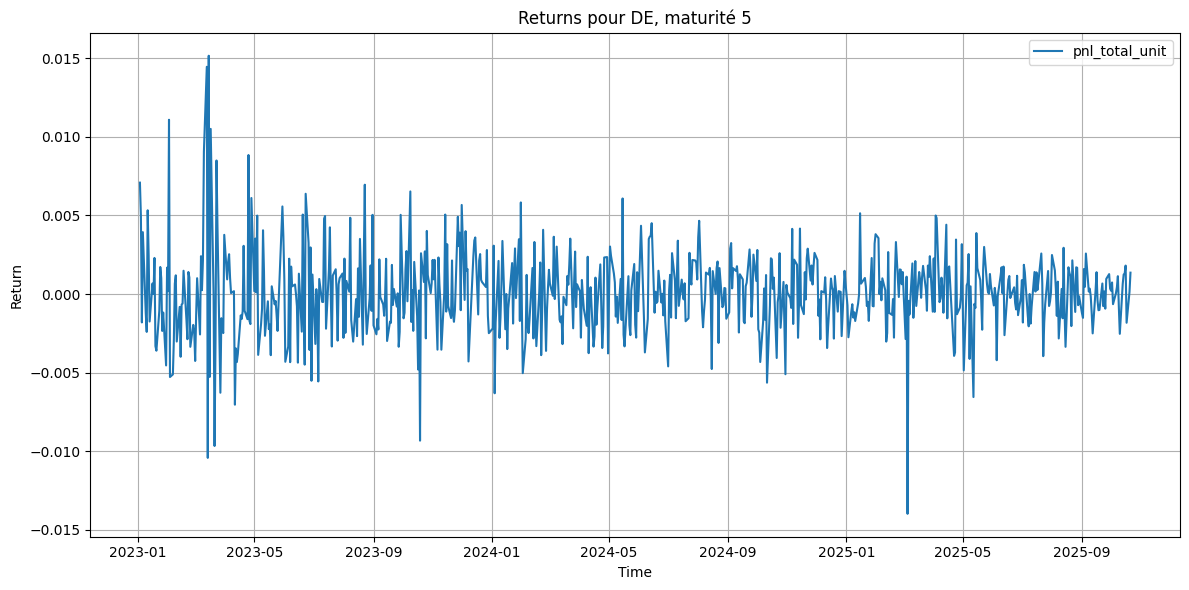

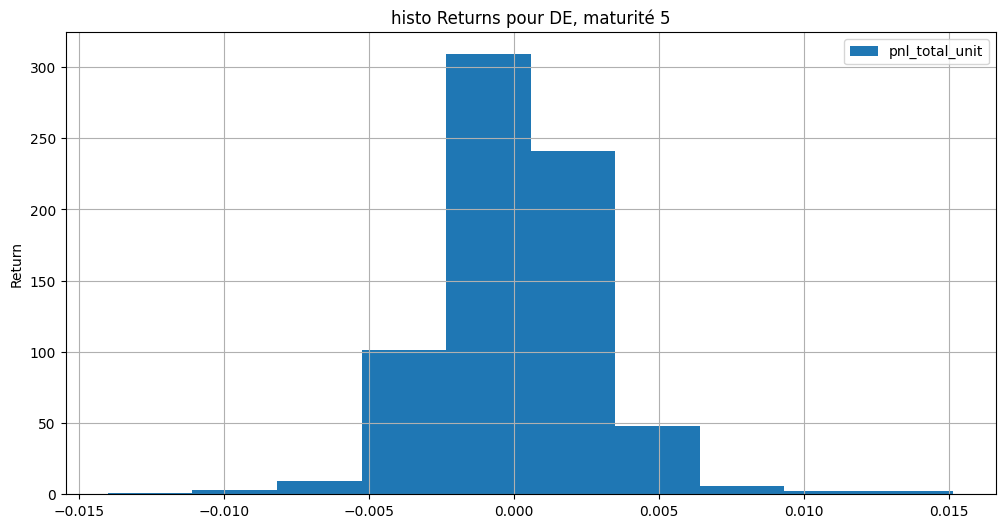

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# -----------------------------
# Variables à modifier facilement
# -----------------------------
country = "DE"                # Pays à filtrer
maturity = "5"                # Maturité à filtrer (valeur de mat_cat)
return_col1 = "ret_total_per_dv01"   # Colonne de return DV01
return_col2 = "pnl_total_unit" # Colonne de coupon quotidien
return_col3 = "pnl_total_unit"    # Colonne de return total

start_date = "2023-01-01"    # Date de début du plot
end_date = "2025-12-31"      # Date de fin du plot

# -----------------------------
# Filtrage du DataFrame
# -----------------------------
df_plot = data.loc[
    (data["country_iso"] == country) &
    (data["mat_cat"] == maturity) &
    (data["time_stamp"] >= pd.to_datetime(start_date)) &
    (data["time_stamp"] <= pd.to_datetime(end_date))
]

# -----------------------------
# Plot avec matplotlib
# -----------------------------
plt.figure(figsize=(12,6))
plt.plot(df_plot["time_stamp"], df_plot[return_col2], label=return_col2, linestyle="-")
plt.title(f"Returns pour {country}, maturité {maturity}")
plt.xlabel("Time")
plt.ylabel("Return")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

plt.figure(figsize=(12,6))
plt.hist(df_plot[return_col2], label=return_col2)
plt.title(f"histo Returns pour {country}, maturité {maturity}")
plt.ylabel("Return")
plt.legend()
plt.grid(True)
plt.show()

In [20]:
#On met data sous le bon format. Ce qu'on veut c'est :
# Date | Finacial product (ex FR_5 pour France bond mat 5) | Return
val1 = "ret_total_per_dv01"
val2 = "pnl_total_unit"

data_completed = data[["time_stamp", "country_iso", "mat_cat", val1, val2, "dv01"]].copy()
data_completed["product"] = data_completed["country_iso"].astype(str) + "_" + data_completed["mat_cat"].astype(str)
data_completed = data_completed.drop(columns=["country_iso", "mat_cat"])
data_completed["time_stamp"] = pd.to_datetime(data_completed["time_stamp"])
dv01_ref = data_completed["dv01"].median()
data_completed.head()




,time_stamp,ret_total_per_dv01,pnl_total_unit,dv01,product
0,2015-01-01,0.023346,0.000022,0.000957,DE_10
1,2015-01-02,4.371456,0.004203,0.000962,DE_10
2,2015-01-05,-1.977655,-0.001896,0.000959,DE_10
3,2015-01-06,7.169240,0.006923,0.000966,DE_10
4,2015-01-07,-3.829079,-0.003681,0.000961,DE_10


## Chargement des bid-offer par bond

In [21]:
bo = pd.read_csv("data/bid_offer_CS.csv")  # adapte le nom si besoin
# Harmonise les types
bo["mat_cat"] = bo["mat_cat"].astype(str)

# On définit le product bond simple : "FR_5", "DE_10", etc.
bo["product"] = bo["country_iso"].astype(str) + "_" + bo["mat_cat"].astype(str)

# On agrège par product (médiane par ex. s'il y a plusieurs ISIN dans le bucket)
bond_bidoffer_yield = (
    bo.groupby("product")["q25_spread_yield"]
    .median()
    .rename("bidoffer_yield_bond")
)
bond_bidoffer_yield_bp = bond_bidoffer_yield 
bond_bidoffer_yield.head()

product
AT_10    0.006
AT_15    0.011
AT_2     0.023
AT_20    0.008
AT_3     0.017
Name: bidoffer_yield_bond, dtype: float64

# Ajout spread et curve 

In [22]:
def add_spread_curve(
    data,
    value_col="pnl_total_unit",
    bond_bidoffer_yield=None
):
    """
    Ajoute au format long (time_stamp, product, value_col) :
      - Obligations "outright" : FR_2, DE_10, ...
      - Spreads entre pays à même maturité      : FR_DE_2        (type = spread_country)
      - Curve Spreads intra-pays                : FR_2_5         (type = spread_curve)
      - Butterflies intra-pays                  : FR_fly_2_5_10  (type = butterfly_curve)
      - Box / Différences de pente entre pays   : FR_DE_slope_2_10 (type = slope_diff_country)

    Paramètres
    ----------
    data : DataFrame
        Colonnes attendues : time_stamp, product, value_col
    value_col : str
        Nom de la colonne de return à utiliser
        (ex: "pnl_total_unit" ou "ret_total_per_dv01")
    bond_bidoffer_yield : Series optionnelle
        index = product (ex: "FR_2"), valeurs = bid/offer en yield pour les bonds simples.

    Retour
    ------
    DataFrame long enrichi avec une colonne 'type'
    et 'bid_offer_yield' si disponible.
    """

    df = data.copy()

    # --- Produits originaux ---
    product_type = {p: "bond" for p in df["product"].unique()}

    # --- Extraction pays / maturités ---
    products = df["product"].unique()
    countries = sorted({p.split("_")[0] for p in products})

    def sort_mats(mats):
        try:
            return sorted(mats, key=lambda x: float(x))
        except ValueError:
            return sorted(mats)

    maturities = sort_mats({p.split("_")[1] for p in products})

    # --- Pivot large ---
    wide = (
        df
        .pivot(index="time_stamp", columns="product", values=value_col)
        .sort_index()
    )

    # --- Bid / offer par produit ---
    bidoffer_product = {}
    if bond_bidoffer_yield is not None:
        for p in wide.columns:
            if p in bond_bidoffer_yield.index:
                bidoffer_product[p] = bond_bidoffer_yield.loc[p]

    # ============================
    # 1) SPREADS ENTRE PAYS
    # ============================
    for mat in maturities:
        prods_mat = [f"{c}_{mat}" for c in countries if f"{c}_{mat}" in wide.columns]

        for i in range(len(prods_mat)):
            for j in range(i + 1, len(prods_mat)):
                p1, p2 = prods_mat[i], prods_mat[j]
                c1, c2 = p1.split("_")[0], p2.split("_")[0]

                spread_name = f"{c1}_{c2}_{mat}"
                if spread_name not in wide.columns:
                    wide[spread_name] = wide[p1] - wide[p2]
                    product_type[spread_name] = "spread_country"

                    if bond_bidoffer_yield is not None:
                        bo1 = bidoffer_product.get(p1, np.nan)
                        bo2 = bidoffer_product.get(p2, np.nan)
                        if np.isfinite(bo1) and np.isfinite(bo2):
                            half_sum = 0.5 * (bo1 + bo2)
                            bidoffer_product[spread_name] = (
                                half_sum * bid_offer_multiplier["spread"]
                            )

    # ============================
    # 2) SPREADS DE COURBE
    # ============================
    for c in countries:
        mats_c = sort_mats([p.split("_")[1] for p in products if p.startswith(c + "_")])

        for i in range(len(mats_c)):
            for j in range(i + 1, len(mats_c)):
                m1, m2 = mats_c[i], mats_c[j]
                p1, p2 = f"{c}_{m1}", f"{c}_{m2}"

                if p1 in wide.columns and p2 in wide.columns:
                    spread_name = f"{c}_{m1}_{m2}"
                    if spread_name not in wide.columns:
                        wide[spread_name] = wide[p1] - wide[p2]
                        product_type[spread_name] = "spread_curve"

                        if bond_bidoffer_yield is not None:
                            bo1 = bidoffer_product.get(p1, np.nan)
                            bo2 = bidoffer_product.get(p2, np.nan)
                            if np.isfinite(bo1) and np.isfinite(bo2):
                                half_sum = 0.5 * (bo1 + bo2)
                                bidoffer_product[spread_name] = (
                                    half_sum * bid_offer_multiplier["curve"]
                                )

    # ============================
    # 3) BUTTERFLIES
    # ============================
    for c in countries:
        mats_c = sort_mats([p.split("_")[1] for p in products if p.startswith(c + "_")])

        for i in range(len(mats_c) - 2):
            m1, m2, m3 = mats_c[i], mats_c[i + 1], mats_c[i + 2]
            p1, p2, p3 = f"{c}_{m1}", f"{c}_{m2}", f"{c}_{m3}"

            if all(p in wide.columns for p in (p1, p2, p3)):
                fly_name = f"{c}_fly_{m1}_{m2}_{m3}"
                if fly_name not in wide.columns:
                    wide[fly_name] = wide[p1] - 2 * wide[p2] + wide[p3]
                    product_type[fly_name] = "butterfly_curve"

                    if bond_bidoffer_yield is not None:
                        bo1 = bidoffer_product.get(p1, np.nan)
                        bo2 = bidoffer_product.get(p2, np.nan)
                        bo3 = bidoffer_product.get(p3, np.nan)
                        if np.isfinite(bo1) and np.isfinite(bo2) and np.isfinite(bo3):
                            half_sum = 0.5 * (bo1 + bo2 + bo3)
                            bidoffer_product[fly_name] = (
                                half_sum * bid_offer_multiplier["fly"]
                            )

    # ============================
    # 4) BOX / SLOPE DIFF
    # ============================
    for idx_low in range(len(maturities) - 1):
        for idx_high in range(idx_low + 1, len(maturities)):
            m_low, m_high = maturities[idx_low], maturities[idx_high]

            for i in range(len(countries)):
                for j in range(i + 1, len(countries)):
                    c1, c2 = countries[i], countries[j]
                    p1_low, p1_high = f"{c1}_{m_low}", f"{c1}_{m_high}"
                    p2_low, p2_high = f"{c2}_{m_low}", f"{c2}_{m_high}"

                    if all(p in wide.columns for p in (p1_low, p1_high, p2_low, p2_high)):
                        slope_name = f"{c1}_{c2}_slope_{m_low}_{m_high}"
                        if slope_name not in wide.columns:
                            wide[slope_name] = (
                                (wide[p1_high] - wide[p1_low]) -
                                (wide[p2_high] - wide[p2_low])
                            )
                            product_type[slope_name] = "slope_diff_country"

                            if bond_bidoffer_yield is not None:
                                bo1_low  = bidoffer_product.get(p1_low,  np.nan)
                                bo1_high = bidoffer_product.get(p1_high, np.nan)
                                bo2_low  = bidoffer_product.get(p2_low,  np.nan)
                                bo2_high = bidoffer_product.get(p2_high, np.nan)

                                if all(np.isfinite(x) for x in [bo1_low, bo1_high, bo2_low, bo2_high]):
                                    half_sum = 0.5 * (bo1_low + bo1_high + bo2_low + bo2_high)
                                    bidoffer_product[slope_name] = (
                                        half_sum * bid_offer_multiplier["box"]
                                    )

    # ============================
    # Retour format long
    # ============================
    long = wide.reset_index().melt(
        id_vars="time_stamp",
        var_name="product",
        value_name=value_col
    )

    long["type"] = long["product"].map(product_type).fillna("unknown")

    if bond_bidoffer_yield is not None:
        bo_series = pd.Series(bidoffer_product)
        long["bid_offer_yield"] = long["product"].map(bo_series)

    return long


In [23]:
bid_offer_multiplier = {
    "fly": 0.25,
    "box": 0.375,
    "spread": 0.5,
    "curve": 0.4,
}

long = add_spread_curve(data_completed,value_col="pnl_total_unit",  bond_bidoffer_yield=bond_bidoffer_yield_bp)
long2 = add_spread_curve(data_completed,value_col="ret_total_per_dv01",  bond_bidoffer_yield=bond_bidoffer_yield_bp)
long_dv01 = add_spread_curve(data_completed, value_col="dv01", bond_bidoffer_yield=None)
dv01_by_product = long_dv01.groupby("product")["dv01"].median()

long["ret_total_per_dv01"] = long2["ret_total_per_dv01"]
long.head(10)

long[long["type"].isin(["bond", "spread_country", "spread_curve", "butterfly_curve", "slope_diff_country"])] \
    .groupby("type")["bid_offer_yield"].describe()


,count,mean,std,min,25%,50%,75%,max
type,,,,,,,,
bond,34920.0,0.008533,0.005476,0.002000,0.004000,0.006000,0.014000,0.020000
butterfly_curve,20952.0,0.002792,0.001402,0.001125,0.001875,0.002125,0.003750,0.005375
slope_diff_country,69840.0,0.006400,0.002084,0.002625,0.004875,0.006562,0.008062,0.010313
spread_country,34920.0,0.004267,0.001948,0.001250,0.002250,0.004250,0.006250,0.007250
spread_curve,69840.0,0.003413,0.001760,0.001000,0.001800,0.003000,0.004600,0.007400


In [24]:
long.head()

,time_stamp,product,pnl_total_unit,type,bid_offer_yield,ret_total_per_dv01
0,2015-01-01,DE_10,0.000022,bond,0.003,0.023346
1,2015-01-02,DE_10,0.004203,bond,0.003,4.371456
2,2015-01-05,DE_10,-0.001896,bond,0.003,-1.977655
3,2015-01-06,DE_10,0.006923,bond,0.003,7.169240
4,2015-01-07,DE_10,-0.003681,bond,0.003,-3.829079


# Class Portfolio à date t 

In [ ]:
class Portfolio:
    def __init__(
        self,
        data,
        date,
        benchmark="ew",
        long_only=True,
        lamb=0.1,
        rebalancement='ME',
        span=6,
        initial_weights=None,
        delta=0.1,
        tc_gamma=0.1
    ):
        """
        Classe Portfolio : initialise un portefeuille pour optimisation Markowitz
        basé sur des returns DV01-normalisés.

        Paramètres
        ----------
        data : pd.DataFrame
            Historique des produits avec au moins les colonnes :
            'time_stamp', 'product', 'pnl_total_unit', éventuellement 'ret_total_per_dv01'.
        date : datetime-like
            Date de rebalancement / estimation. Seules les données avant cette date sont utilisées.
        benchmark : str, default "ew"
            Nom du benchmark pour comparaison (ex: equal-weighted).
        long_only : bool, default True
            Si True, les poids sont projetés sur le simplexe (pas de short).
        lamb : float, default 1.0
            Paramètre d’aversion au risque λ pour Markowitz : maximise μ'w - λ w'Σw.
        rebalancement : str, default 'ME'
            Fréquence de rebalancement :
            'D' = quotidien, 'W' = hebdomadaire, 'M' = mensuel, 'ME' = fin de mois.
        span : int, default 6
            Demi-vie pour calcul EWMA des retours moyens.
        initial_weights : array-like or None, default None
            Poids initiaux du portefeuille, pour démarrer l’optimisation.
        delta : float, default 0.1
            Paramètre de régularisation / limite de variation de poids.
        tc_gamma : float, default 0.1
            Coefficient de coût de transaction.

        Attributs internes
        ------------------
        self.data : pd.DataFrame
        self.date : pd.Timestamp
        self.benchmark : str
        self.long_only : bool
        self.lamb : float
        self.rebalancement : str
        self.sigma_level : float
        self.span : int
        self.initial_weights : array-like or None
        self.delta : float
        self.tc_gamma : float

        self.returns : pd.DataFrame
            Returns filtrés jusqu'à self.date.
        self.mean_returns : pd.DataFrame or pd.Series
            Moyenne des retours (EWMA).
        self.cov_matrix : pd.DataFrame
            Matrice de covariance des returns.
        self.weights : pd.Series or np.array
            Poids optimisés pour la période courante.
        self.benchmark_weights : pd.Series or np.array
            Poids du benchmark pour comparaison.
        """

        # --- données et date ---
        self.data = data
        self.date = pd.to_datetime(date)
        self.benchmark = benchmark

        # --- paramètres optimisation ---
        self.long_only = long_only
        self.lamb = float(lamb)
        self.rebalancement = rebalancement
        self.span = span
        self.delta = delta
        self.tc_gamma = float(tc_gamma)
        self.initial_weights = initial_weights

        # --- attributs internes ---
        self.returns = None
        self.mean_returns = None
        self.cov_matrix = None
        self.weights = None
        self.benchmark_weights = None

    def get_returns_until(self):
        """Filter returns up to self.date and resample according to rebalancement."""
        R = self.data[self.data["time_stamp"] < self.date].copy()

        # --- resampling selon la fréquence de rebalancement ---
        if hasattr(self, "rebalancement") and self.rebalancement in ["D", "W", "ME"]:
            df_list = []
            for prod, df_prod in R.groupby("product"):
                df_prod = df_prod.set_index("time_stamp").sort_index()
                if self.rebalancement != "D":
                    df_resampled = df_prod["ret_total_per_dv01"].resample(self.rebalancement).sum()
                else:
                    df_resampled = df_prod["ret_total_per_dv01"]
                df_resampled = df_resampled.reset_index()
                df_resampled["product"] = prod
                df_list.append(df_resampled)
            R = pd.concat(df_list, axis=0)
        else:
            # default = daily
            R = R.copy()

        self.returns = R.sort_values(["product", "time_stamp"])


    def estimate_returns(self):
        """EWMA (exponential weighted mean) of returns per product."""
        span = self.span  # span controlling the half-life

        # on prend seulement date, produit et return
        df = self.returns[["time_stamp", "product", "ret_total_per_dv01"]].copy()
        df = df.sort_values(["product", "time_stamp"])

        # --- EWMA par produit ---
        ewma = (
            df.groupby("product")["ret_total_per_dv01"]
            .apply(lambda x: x.ewm(span=span, adjust=False).mean().iloc[-1])
            .reset_index(name="ewma_ret_dv01")
        )

        self.mean_returns = ewma

    def estimate_cov_matrix_Ledoit(self):
        """
        Estimate covariance matrix using Ledoit-Wolf shrinkage.
        """
        panel = self.returns.pivot(
            index="time_stamp",
            columns="product",
            values="ret_total_per_dv01"
        ).sort_index()

        X = panel.fillna(0).values
        lw = LedoitWolf().fit(X)     
        cov_matrix = lw.covariance_

        self.cov_matrix = pd.DataFrame(
            cov_matrix,
            columns=panel.columns,
            index=panel.columns
        )
        
    def markowitz2_qp(self):
        """
        Version QP de Markowitz avec coûts de transaction linéaires en turnover.
        """

        # 1) μ et Σ
        mean = self.mean_returns.set_index("product")["ewma_ret_dv01"]
        mean = mean.reindex(self.cov_matrix.index).fillna(0.0)
        mean_returns = mean.values

        Sigma = self.cov_matrix.values
        n = len(mean_returns)
        lambda_risk = self.lamb
        gamma_tc = self.tc_gamma
        long_only = self.long_only

        # --- PATCH NUMERIQUE SUR Σ ---
        Sigma = 0.5 * (Sigma + Sigma.T)         # symétrisation
        Sigma = Sigma + 1e-8 * np.eye(n)        # régularisation diagonale

        # 2) w_prev aligné
        if self.initial_weights is None:
            if long_only:
                w_prev = np.ones(n) / n
            else:
                w_prev = np.zeros(n)
        else:
            if isinstance(self.initial_weights, pd.Series):
                w_prev_series = self.initial_weights.reindex(self.cov_matrix.index).fillna(0.0)
                w_prev = w_prev_series.values
            elif isinstance(self.initial_weights, pd.DataFrame):
                w_prev_series = self.initial_weights.iloc[:, 0]
                w_prev_series = w_prev_series.reindex(self.cov_matrix.index).fillna(0.0)
                w_prev = w_prev_series.values
            else:
                w_prev = np.asarray(self.initial_weights, dtype=float)
                if w_prev.shape[0] != n:
                    raise ValueError("initial_weights non compatible avec la dimension de la covariance.")

        # Si market-neutral, recentre w_prev
        if not long_only:
            w_prev = w_prev - w_prev.mean()

        # 3) c_vec depuis bid_offer_yield
        if "bid_offer_yield" in self.data.columns:
            bo = (
                self.data.groupby("product")["bid_offer_yield"]
                .median()
                .reindex(self.cov_matrix.index)
                .fillna(0.0)
            )
            c_vec = bo.values
        else:
            c_vec = np.zeros(n)

        # 4) Variables
        w = cp.Variable(n)
        t = cp.Variable(n)

        # 5) Bornes dynamiques
        if long_only:
            w_min = np.zeros(n)
            w_max = w_prev + self.delta
        else:
            w_min = w_prev - self.delta
            w_max = w_prev + self.delta

        # 6) Contraintes
        target_sum = 1.0 if long_only else 0.0
        constraints = [
            cp.sum(w) == target_sum,
            w >= w_min,
            w <= w_max,
            t >= w - w_prev,
            t >= -(w - w_prev),
            t >= 0
        ]

        # 7) Objectif
        quad_term = lambda_risk * cp.quad_form(w, cp.psd_wrap(Sigma))
        mean_term = - mean_returns @ w
        if gamma_tc > 0 and np.any(c_vec != 0):
            tc_term = gamma_tc * (c_vec @ t)
        else:
            tc_term = 0

        objective = cp.Minimize(quad_term + mean_term + tc_term)

        # 8) Résolution
        prob = cp.Problem(objective, constraints)
        try:
            prob.solve(solver=cp.OSQP, verbose=False)
        except Exception:
            prob.solve(solver=cp.SCS, verbose=False)

        if w.value is None:
            raise ValueError("Optimisation QP échouée : statut = " + prob.status)

        w_opt = np.array(w.value).flatten()

        # 9) Nettoyage
        threshold = 1e-4
        w_opt[np.abs(w_opt) < threshold] = 0.0

        if long_only:
            s = w_opt.sum()
            if s != 0:
                w_opt = w_opt / s
        else:
            gross = np.sum(np.abs(w_opt))
            if gross > 0:
                w_opt = w_opt / gross

        self.weights = pd.DataFrame(w_opt, index=self.cov_matrix.index, columns=[self.date])
        return self.weights




    def markowitz2(self):

        # ---- 1) Vecteur de rendements attendus ----
        mean = self.mean_returns.set_index("product")["ewma_ret_dv01"]
        mean = mean.reindex(self.cov_matrix.index).fillna(0.0)
        mean_returns = mean.values

        cov_matrix = self.cov_matrix.values
        n = len(mean_returns)
        lambda_risk = self.lamb
        long_only = self.long_only
        gamma_tc = getattr(self, "tc_gamma", 0.0)
        eps_tc = 1e-8  # pour lisser |x| ≈ sqrt(x^2 + eps)

        # ---- 2) Poids précédents (w_prev), correctement alignés ----
        if self.initial_weights is None:
            w_prev = np.ones(n) / n
        else:
            if isinstance(self.initial_weights, pd.Series):
                w_prev_series = self.initial_weights.reindex(self.cov_matrix.index).fillna(0.0)
                w_prev = w_prev_series.values
            elif isinstance(self.initial_weights, pd.DataFrame):
                # on prend la première colonne si DataFrame
                w_prev_series = self.initial_weights.iloc[:, 0]
                w_prev_series = w_prev_series.reindex(self.cov_matrix.index).fillna(0.0)
                w_prev = w_prev_series.values
            else:
                # numpy array ou liste
                w_prev = np.asarray(self.initial_weights, dtype=float)
                if w_prev.shape[0] != n:
                    raise ValueError("initial_weights non compatible avec la dimension de la covariance.")

        # ---- 3) Coefficients de coût c_i à partir des bid_offer_yield ----
        if ("bid_offer_yield" in self.data.columns):
            # médiane sur l’historique pour chaque product
            bo = (
                self.data.groupby("product")["bid_offer_yield"]
                .median()
                .reindex(self.cov_matrix.index)
                .fillna(0.0)
            )
            c_vec = bo.values
        else:
            c_vec = np.zeros(n)

        # ---- 4) Fonction objectif avec coûts de transaction ----
        def objective(w):
            # risque
            risk_term = lambda_risk * (w @ cov_matrix @ w)
            # rendement
            mean_term = - (w @ mean_returns)
            # coût de transaction
            if gamma_tc > 0.0 and np.any(c_vec != 0):
                diff = w - w_prev
                tc_term = gamma_tc * np.sum(c_vec * np.sqrt(diff * diff + eps_tc))
            else:
                tc_term = 0.0
            return risk_term + mean_term + tc_term

        # ---- 5) Gradient de l’objectif ----
        def grad_objective(w):
            # dérivée risk
            grad_risk = 2.0 * lambda_risk * (cov_matrix @ w)
            # dérivée rendement
            grad_mean = -mean_returns
            # dérivée coût de transaction
            if gamma_tc > 0.0 and np.any(c_vec != 0):
                diff = w - w_prev
                denom = np.sqrt(diff * diff + eps_tc)
                grad_tc = gamma_tc * c_vec * (diff / denom)
            else:
                grad_tc = np.zeros_like(w)
            return grad_risk + grad_mean + grad_tc

        # ---- 6) Contraintes et bornes ----
        constraints = [
            {'type': 'eq',
            'fun': lambda w: np.sum(w) - 1.0,
            'jac': lambda w: np.ones_like(w)}
        ]

        # Bornes dynamiques (comme ta V2)
        bounds = []
        if long_only:
            for wp in w_prev:
                # poids min 0, max wp + delta
                bounds.append((max(0,wp - self.delta), wp + self.delta))
        else:
            for wp in w_prev:
                bounds.append((wp - self.delta, wp + self.delta))


        # ---- 7) Initialisation ----
        w0 = np.clip(w_prev, [b[0] for b in bounds], [b[1] for b in bounds])
        if w0.sum() == 0:
            w0 = np.ones(n) / n
        else:
            w0 = w0 / w0.sum()



        # ---- 9) Nettoyage / normalisation ----
        threshold = 1e-4
        w_opt[np.abs(w_opt) < threshold] = 0.0
        if w_opt.sum() != 0:
            w_opt = w_opt / w_opt.sum()

        self.weights = pd.DataFrame(w_opt, index=self.cov_matrix.index, columns=[self.date])
        return self.weights

    def markowitz_robust(self):
        """
        Optimisation Markowitz robuste avec contrôle du turnover.
        - mean_returns et cov_matrix doivent être déjà définis.
        - long_only : si True, les poids >= 0
        - delta : limite de variation des poids par rapport à w_prev
        - gamma_tc : poids du coût de transaction
        """
        # ---- 1) Rendements attendus et covariance ----
        mean_returns = self.mean_returns.set_index("product")["ewma_ret_dv01"]
        mean_returns = mean_returns.reindex(self.cov_matrix.index).fillna(0.0).values
        cov_matrix = self.cov_matrix.values
        n = len(mean_returns)

        # ---- 2) Poids précédents ----
        if self.initial_weights is None:
            if self.long_only:
                w_prev = np.ones(n) / n
            else:
                w_prev = np.zeros(n)
        else:
            if isinstance(self.initial_weights, pd.Series):
                w_prev = self.initial_weights.reindex(self.cov_matrix.index).fillna(0.0).values
            elif isinstance(self.initial_weights, pd.DataFrame):
                w_prev = self.initial_weights.iloc[:, 0].reindex(self.cov_matrix.index).fillna(0.0).values
            else:
                w_prev = np.asarray(self.initial_weights, dtype=float)
                if w_prev.shape[0] != n:
                    raise ValueError("initial_weights non compatible avec la dimension de la covariance.")

        # market-neutral: recentrer
        if not self.long_only:
            w_prev = w_prev - w_prev.mean()

        # ---- 3) Coût de transaction ----
        if "bid_offer_yield" in self.data.columns:
            c_vec = (
                self.data.groupby("product")["bid_offer_yield"]
                .median().reindex(self.cov_matrix.index).fillna(0.0).values
            )
        else:
            c_vec = np.zeros(n)

        lambda_risk = self.lamb
        gamma_tc = getattr(self, "tc_gamma", 0.0)
        eps_tc = 1e-8

        # ---- 4) Fonction objectif ----
        def objective(w):
            risk_term = lambda_risk * (w @ cov_matrix @ w)
            mean_term = -(w @ mean_returns)
            if gamma_tc > 0.0 and np.any(c_vec != 0):
                diff = w - w_prev
                tc_term = gamma_tc * np.sum(c_vec * np.sqrt(diff**2 + eps_tc))
            else:
                tc_term = 0.0
            return risk_term + mean_term + tc_term

        # ---- 5) Gradient ----
        def grad_objective(w):
            grad_risk = 2.0 * lambda_risk * (cov_matrix @ w)
            grad_mean = -mean_returns
            if gamma_tc > 0.0 and np.any(c_vec != 0):
                diff = w - w_prev
                grad_tc = gamma_tc * c_vec * (diff / np.sqrt(diff**2 + eps_tc))
            else:
                grad_tc = np.zeros_like(w)
            return grad_risk + grad_mean + grad_tc

        # ---- 6) Contraintes ----
        target_sum = 1.0 if self.long_only else 0.0
        constraints = [{'type': 'eq',
                        'fun': lambda w: np.sum(w) - target_sum,
                        'jac': lambda w: np.ones_like(w)}]

        # ---- 7) Bornes ----
        bounds = []
        if self.long_only:
            for wp in w_prev:
                bounds.append((max(0.0, wp - self.delta), wp + self.delta))
        else:
            for wp in w_prev:
                bounds.append((wp - self.delta, wp + self.delta))

        # ---- 8) Initialisation ----
        w0 = w_prev.copy()

        # ---- 9) Optimisation ----
        res = minimize(
            objective, w0, jac=grad_objective,
            constraints=constraints, bounds=bounds,
            method='SLSQP',
            options={'ftol': 1e-9, 'disp': False, 'maxiter': 1000}
        )

        if not res.success:
            print(f"Optimisation échouée à {self.date}, on reprend les poids précédents")
            w_opt = w_prev.copy()
        else:
            w_opt = res.x

        # ---- 10) Nettoyage ----
        threshold = 1e-4
        w_opt[np.abs(w_opt) < threshold] = 0.0

        # normalisation finale (utile pour stabilité)
        if self.long_only:
            s = w_opt.sum()
            if s != 0:
                w_opt = w_opt / s
        else:
            gross = np.sum(np.abs(w_opt))
            if gross > 0:
                w_opt = w_opt / gross

        # ---- 11) Retour ----
        self.weights = pd.DataFrame(w_opt, index=self.cov_matrix.index, columns=[self.date])
        return self.weights




    def benchmark_w(self):
        n = len(self.mean_returns)
        if self.benchmark == "ew":
            self.benchmark_weights = pd.DataFrame(np.ones(n) / n,index=self.mean_returns["product"], columns=[self.date])
        else:
            raise NotImplementedError("Only 'ew' benchmark implemented for now.")

    def process(self, use_qp=False):
        self.get_returns_until()
        self.estimate_returns()
        self.estimate_cov_matrix_Ledoit()

        """        
        if use_qp:
            self.markowitz2_qp()
        else:
            self.markowitz2()   # ta version SLSQP existante
        """
        self.markowitz_robust()
        self.benchmark_w()
        return self.weights



In [26]:
date = "2021-06-01"


pf = Portfolio(long, date, benchmark="ew", long_only=True,lamb=0.1)
#print(pf.returns)
w = pf.process() 
#print(pf.mean_returns)
print(w)

                 2021-06-01
product                    
DE_10              0.000000
DE_10_15           0.000000
DE_10_30           0.000000
DE_15              0.000000
DE_15_30           0.000000
...                     ...
IT_5_15            0.110101
IT_5_30            0.110101
IT_fly_10_15_30    0.000000
IT_fly_2_5_10      0.000000
IT_fly_5_10_15     0.000000

[99 rows x 1 columns]


# Creation du time series portfolio

In [27]:
class TimeSeriesPortfolio:
    def __init__(self, data, start_date, end_date, rebalance_freq='ME',
                 long_only=False, lamb=0.1, benchmark="ew", 
                capital_init=100_000, span = 6, initial_weights= None, delta = 0.1, tc_gamma=0.0, use_qp=False):

        # Convert time_stamp to Timestamp
        self.data = data.copy()
        self.data["time_stamp"] = pd.to_datetime(self.data["time_stamp"])
        self.start_date = pd.to_datetime(start_date)
        self.end_date = pd.to_datetime(end_date)
        self.rebalance_freq = rebalance_freq
        self.long_only = long_only
        self.lamb = float(lamb)
        self.benchmark = benchmark
        self.capital_init = capital_init
        self.span = span
        
        self.tc_gamma = float(tc_gamma)
        self.use_qp = bool(use_qp)

        self.delta = delta
        self.initial_weights = initial_weights
        
        # Univers global d'actifs (tous les products jamais vus dans self.data)
        self.asset_universe = sorted(self.data["product"].unique())
        
        self.countries = sorted({p.split("_")[0] for p in self.asset_universe})

        self.rebalance_dates = None
        self.all_dates = None
        self.weights_history = pd.DataFrame()
        self.exposures_history = pd.DataFrame()
        self.portfolio_returns = pd.Series(dtype=float)
        self.benchmark_returns = pd.Series(dtype=float)
        self.metrics = {}

        # *** Séries de bid-offer par produit (en yield), agrégées sur le temps
        if "bid_offer_yield" in self.data.columns:
            # médiane sur l'historique, par product
            self.bidoffer_by_product = (
                self.data.groupby("product")["bid_offer_yield"]
                .median()
                .rename("bid_offer_yield")
            )
        else:
            # pas d'info => 0
            self.bidoffer_by_product = pd.Series(0.0, index=self.asset_universe)

        # Filter data for rolling window
        start_window = self.start_date - pd.Timedelta(days=5_000)
        self.R = self.data[
            (self.data["time_stamp"] >= start_window) &
            (self.data["time_stamp"] <= self.end_date)
        ]

    def freq_to_pd_freq(self):
        f = self.rebalance_freq.upper()
        if f == 'ME':
            return f
        if f.endswith(('D', 'B', 'W')):
            return f
        return 'ME'

    def generate_rebalance_dates(self):
        all_dates = pd.DatetimeIndex(self.R["time_stamp"].unique())
        mask = (all_dates >= self.start_date) & (all_dates <= self.end_date)
        all_dates = all_dates[mask].sort_values()
        self.all_dates = all_dates

        if len(all_dates) == 0:
            raise ValueError("No market dates in the selected window.")

        targets = pd.date_range(start=self.start_date, end=self.end_date,
                                freq=self.freq_to_pd_freq())
        reb = []
        for tgt in targets:
            tgt = pd.Timestamp(tgt)  # assure tz-naive Timestamp
            pos = all_dates.searchsorted(tgt)
            if pos < len(all_dates):
                d = all_dates[pos]
                if (len(reb) == 0) or (d != reb[-1]):
                    reb.append(d)

        if all_dates[-1] not in reb:
            reb.append(all_dates[-1])

        self.rebalance_dates = pd.DatetimeIndex(reb)

    def generate_portfolios(self):
        if self.rebalance_dates is None or self.all_dates is None:
            self.generate_rebalance_dates()

        weights_list = []
        exposures_list = []

        pf_rel_returns = []
        bm_rel_returns= []
        returns_dates = []

        pf_pnl_daily = []
        bm_pnl_daily = []

        # *** tracking des coûts de transaction
        tc_dates = []
        tc_values = []

        capital = self.capital_init
        current_value = capital
        current_value_bm = capital
        w = self.initial_weights

        # *** expositions précédentes (pour calculer les deltas)
        prev_exposure_full = pd.Series(0.0, index=self.asset_universe)

        # *** vecteur de bid-offer aligné sur l'univers global
        bo_full = self.bidoffer_by_product.reindex(self.asset_universe).fillna(0.0)

        for i, t in enumerate(self.rebalance_dates[:-1]):
            t_next = self.rebalance_dates[i + 1]
            
            pf = Portfolio(
                data=self.data,
                date=t,
                benchmark=self.benchmark,
                long_only=self.long_only,
                lamb=self.lamb,
                span=self.span,
                initial_weights=w,
                delta=self.delta,
                tc_gamma=self.tc_gamma,   # <--- important
            )
            
            w_df = pf.process()

            w = w_df.iloc[:, 0]  # Series: index = produits présents dans Σ à cette date

            # 1) Reindexer les poids sur l'univers global, en mettant 0 où l'actif n'est pas dans Σ
            w_full = w.reindex(self.asset_universe).fillna(0.0)

            # Benchmark
            w_bm = pf.benchmark_weights.reindex(self.asset_universe).iloc[:, 0].fillna(0.0)

            # 2) Normalisation des expositions 
            target_dv01 = self.capital_init * dv01_ref 
            denom_pf = np.sum(np.abs(w_full.values))
            if denom_pf > 0:
                exposure_full = w_full * (target_dv01 / denom_pf)
            else:
                exposure_full = w_full.copy()

            denom_bm = np.sum(np.abs(w_bm.values))
            if denom_bm > 0:
                exposure_bm_full = w_bm * (target_dv01 / denom_bm)
            else:
                exposure_bm_full = w_bm.copy()

            # *** 2bis) Coût de transaction du rebalance (en PnL)
            # delta d'exposition (nouveau - ancien) sur chaque produit
            delta_exposure_full = exposure_full - prev_exposure_full

            # coût total = somme |delta_expo| * bid_offer_yield_effectif
            # (bid_offer_yield est déjà une "demi-spread" efficace par ton design)
            #tc_total = np.sum(np.abs(delta_exposure_full.values) * bo_full.values)
            # dv01 par produit (bp price impact)
            dv01_full = self.dv01_by_product.reindex(self.asset_universe).fillna(0.0).values

            # bid/offer en bp (q25_spread_yield est en décimal -> *1e4)
            bo_bp = bo_full.values * 100

            tc_total = np.sum(np.abs(delta_exposure_full.values) * bo_bp)

            # on met à jour les expositions précédentes
            prev_exposure_full = exposure_full.copy()

            # 3) Slice des PnL unitaires pour la période (t, t_next]
            period_mask = (self.R["time_stamp"] > t) & (self.R["time_stamp"] <= t_next)
            R_slice_long = self.R.loc[period_mask].copy()

            R_slice = R_slice_long.pivot(
                index="time_stamp",
                columns="product",
                values="ret_total_per_dv01"
            )

            # On garde uniquement les colonnes de l’univers global (intersection)
            common_cols = [p for p in self.asset_universe if p in R_slice.columns]
            R_slice = R_slice[common_cols].fillna(0.0)

            # 4) Aligner les expositions sur ces colonnes
            exp_pf = exposure_full.reindex(common_cols).values
            exp_bm = exposure_bm_full.reindex(common_cols).values

            # 5) PnL par jour (mid-market)
            pf_pnl_day = R_slice.values @ exp_pf
            bm_pnl_day = R_slice.values @ exp_bm

            # *** Intégration du coût de transaction au PnL du portefeuille
            if len(pf_pnl_day) > 0:
                # on impute le coût le jour du rebalance (premier jour de la période)
                pf_pnl_day[0] -= tc_total
                tc_dates.append(R_slice.index[0])
            else:
                # cas rare où il n'y aurait pas de date entre t et t_next :
                # on enregistre le coût à la date de rebalance t
                tc_dates.append(t)
                # on ajoute un PnL "artificiel" -tc_total
                pf_pnl_day = np.array([-tc_total])
                bm_pnl_day = np.array([0.0])
                # on ajoute aussi une pseudo-date
                R_slice = pd.DataFrame(
                    index=[t],
                    data=np.zeros((1, len(common_cols))),
                    columns=common_cols
                )

            tc_values.append(tc_total)

            pf_pnl_daily.extend(pf_pnl_day)
            bm_pnl_daily.extend(bm_pnl_day)

            pf_rel_returns.extend((pf_pnl_day / current_value).tolist())
            bm_rel_returns.extend((bm_pnl_day / current_value_bm).tolist())
            returns_dates.extend(R_slice.index.tolist())

            current_value += pf_pnl_day.sum()
            current_value_bm += bm_pnl_day.sum()

            # 6) Stocker les poids / expositions sur l’univers global
            weights_list.append(w_full.values)
            exposures_list.append(exposure_full.values)

        asset_names = self.asset_universe
        self.weights_history = pd.DataFrame(
            weights_list,
            index=self.rebalance_dates[:-1],
            columns=asset_names
        )
        self.exposures_history = pd.DataFrame(
            exposures_list,
            index=self.rebalance_dates[:-1],
            columns=asset_names
        )


        if len(returns_dates) > 0:
            self.portfolio_returns = pd.Series(pf_rel_returns, index=pd.DatetimeIndex(returns_dates))
            self.benchmark_returns = pd.Series(bm_rel_returns, index=pd.DatetimeIndex(returns_dates))

        # Cumulative return
        pf_cum_return = (1 + self.portfolio_returns.fillna(0)).cumprod()
        bm_cum_return = (1 + self.benchmark_returns.fillna(0)).cumprod()

        # Cumulative PnL
        pf_value = pd.Series(capital + np.array(pf_pnl_daily).cumsum(), index=pd.DatetimeIndex(returns_dates))
        bm_value = pd.Series(capital + np.array(bm_pnl_daily).cumsum(), index=pd.DatetimeIndex(returns_dates))
        pf_pnl = pd.Series(pf_pnl_daily, index=pd.DatetimeIndex(returns_dates))
        bm_pnl = pd.Series(bm_pnl_daily, index=pd.DatetimeIndex(returns_dates))

        trading_days = 252
        pf_mean = self.portfolio_returns.mean()
        pf_std = self.portfolio_returns.std()
        pf_sharpe = (pf_mean / pf_std * np.sqrt(trading_days)) if pf_std != 0 else np.nan

        # Metrics
        roll_max = pf_value.cummax() if len(pf_value) > 0 else pd.Series(dtype=float)
        dd = (pf_value - roll_max) / roll_max if len(pf_value) > 0 else pd.Series(dtype=float)

        # *** série des coûts de transaction
        tc_series = pd.Series(tc_values, index=pd.DatetimeIndex(tc_dates))

        self.metrics = {
            "initial_capital": capital,
            "portfolio_value": pf_value,
            "benchmark_value": bm_value,
            "portfolio_pnl": pf_pnl,
            "benchmark_pnl": bm_pnl,
            "pf_cumulative_return": pf_cum_return,
            "bm_cumulative_return": bm_cum_return,
            "mean_return": pf_mean,
            "volatility": pf_std,
            "sharpe": pf_sharpe,
            "gross_exposure": np.abs(self.exposures_history).sum(axis=1),
            "net_exposure": self.exposures_history.sum(axis=1),
            "drawdown": dd,
            "max_drawdown": dd.min() if len(dd) > 0 else np.nan,
            "transaction_costs": tc_series,     # *** nouvelle entrée
        }

        print("Tout a marché !!")

    
    def _decompose_product_legs(self, product):
        """
        Décompose un product en jambes élémentaires (country, maturity, coef).

        Conventions de nommage gérées :
          - Bond simple           : FR_5
          - Spread pays           : FR_DE_5              -> +FR_5, -DE_5
          - Spread courbe         : FR_2_5 ou FR_10_5    -> +FR_2/10, -FR_5
          - Butterfly intra-pays  : FR_fly_2_5_10        -> +FR_2, -2 FR_5, +FR_10
          - Slope diff pays       : FR_DE_slope_2_10     -> (FR_10 - FR_2) - (DE_10 - DE_2)

        Retourne une liste de tuples (country, maturity, coef).
        """
        parts = product.split("_")

        # Bond simple : "FR_5"
        if len(parts) == 2:
            c, m = parts
            return [(c, m, 1.0)]

        # Cas len(parts) == 3 : soit spread pays FR_DE_5, soit spread courbe FR_2_5 / FR_10_5
        if len(parts) == 3:
            p0, p1, p2 = parts

            # On utilise la vraie liste de pays pour décider
            # 1) Spread pays : FR_DE_5
            if p0 in getattr(self, "countries", []) and p1 in getattr(self, "countries", []):
                c1, c2, mat = p0, p1, p2
                return [(c1, mat,  1.0),
                        (c2, mat, -1.0)]

            # 2) Spread courbe : FR_2_5, FR_10_5, etc.
            if p0 in getattr(self, "countries", []):
                c, m1, m2 = p0, p1, p2
                return [(c, m1,  1.0),
                        (c, m2, -1.0)]

        # Butterfly : FR_fly_2_5_10
        if len(parts) == 5 and parts[1] == "fly":
            c, _, m1, m2, m3 = parts
            return [(c, m1,  1.0),
                    (c, m2, -2.0),
                    (c, m3,  1.0)]

        # Slope diff pays : FR_DE_slope_2_10
        if len(parts) == 5 and parts[2] == "slope":
            c1, c2, _, m_low, m_high = parts
            return [
                (c1, m_high,  1.0),
                (c1, m_low,  -1.0),
                (c2, m_high, -1.0),
                (c2, m_low,   1.0),
            ]

        # Cas non reconnu : on ignore
        return []

    
    def exposition_by_country(self):
        """
        Calcule l'exposition par pays en tenant compte des combinaisons linéaires
        des produits (bonds, spreads, butterflies, slopes).

        Pour chaque produit j et chaque jour t :
        expo_country[c, t] = somme_j ( expo_j(t) * coef_{j,c,*} )
        où coef_{j,c,*} vient de la décomposition en jambes (country, maturity, coef).
        """
        df = self.exposures_history.copy()  # index = dates, columns = products

        # Pré-calcul des jambes pour chaque produit
        legs_by_product = {}
        countries = set()

        for p in df.columns:
            legs = self._decompose_product_legs(p)
            legs_by_product[p] = legs
            for c, m, coef in legs:
                countries.add(c)

        if not countries:
            # Aucun produit reconnu -> on renvoie un DF vide mais bien formé
            return pd.DataFrame(index=df.index)

        # DataFrame resultat : dates x pays
        countries = sorted(countries)
        expo_by_country = pd.DataFrame(0.0, index=df.index, columns=countries)

        # Agrégation : pour chaque produit, répartir son expo sur les pays
        for p in df.columns:
            legs = legs_by_product.get(p, [])
            if not legs:
                continue
            exp_p = df[p]  # Series index=date

            for c, m, coef in legs:
                expo_by_country[c] += coef * exp_p

        return expo_by_country
    
    def exposition_by_mat(self):
        """
        Calcule l'exposition par maturité (toutes devises confondues) en tenant
        compte des combinaisons linéaires des produits.

        Pour chaque produit j et chaque jour t :
        expo_mat[m, t] = somme_j ( expo_j(t) * coef_{j,*,m} )
        """
        df = self.exposures_history.copy()  # index = dates, columns = products

        legs_by_product = {}
        maturities = set()

        for p in df.columns:
            legs = self._decompose_product_legs(p)
            legs_by_product[p] = legs
            for c, m, coef in legs:
                maturities.add(m)

        if not maturities:
            return pd.DataFrame(index=df.index)

        maturities = sorted(maturities, key=lambda x: float(x) if str(x).replace(".", "", 1).isdigit() else x)
        expo_by_mat = pd.DataFrame(0.0, index=df.index, columns=maturities)

        for p in df.columns:
            legs = legs_by_product.get(p, [])
            if not legs:
                continue
            exp_p = df[p]

            for c, m, coef in legs:
                expo_by_mat[m] += coef * exp_p

        return expo_by_mat





In [28]:
long

,time_stamp,product,pnl_total_unit,type,bid_offer_yield,ret_total_per_dv01
0,2015-01-01,DE_10,0.000022,bond,0.00300,0.023346
1,2015-01-02,DE_10,0.004203,bond,0.00300,4.371456
2,2015-01-05,DE_10,-0.001896,bond,0.00300,-1.977655
3,2015-01-06,DE_10,0.006923,bond,0.00300,7.169240
4,2015-01-07,DE_10,-0.003681,bond,0.00300,-3.829079
...,...,...,...,...,...,...
230467,2025-10-15,FR_IT_slope_15_30,NaN,slope_diff_country,0.00825,NaN
230468,2025-10-16,FR_IT_slope_15_30,NaN,slope_diff_country,0.00825,NaN
230469,2025-10-17,FR_IT_slope_15_30,NaN,slope_diff_country,0.00825,NaN
230470,2025-10-20,FR_IT_slope_15_30,NaN,slope_diff_country,0.00825,NaN


In [29]:
L = long.groupby("product")["pnl_total_unit"].mean().index
weights_dict = {p: 0.0 for p in L}
#print(L)
weights_dict['DE_10'] = 0.1
weights_dict['FR_10'] = 0.2
weights_dict['IT_5'] = 0.7

df_weights = pd.DataFrame(list(weights_dict.items()), columns=['product', 'weight'])

In [30]:
df_weights

,product,weight
0,DE_10,0.1
1,DE_10_15,0.0
2,DE_10_30,0.0
3,DE_15,0.0
4,DE_15_30,0.0
...,...,...
94,IT_5_15,0.0
95,IT_5_30,0.0
96,IT_fly_10_15_30,0.0
97,IT_fly_2_5_10,0.0


c:\Users\youne\miniconda3\envs\qrt\lib\site-packages\scipy\optimize\_slsqp_py.py:435: RuntimeWarning: Values in x were outside bounds during a minimize step, clipping to bounds
  fx = wrapped_fun(x)
c:\Users\youne\miniconda3\envs\qrt\lib\site-packages\scipy\optimize\_slsqp_py.py:435: RuntimeWarning: Values in x were outside bounds during a minimize step, clipping to bounds
  fx = wrapped_fun(x)
c:\Users\youne\miniconda3\envs\qrt\lib\site-packages\scipy\optimize\_slsqp_py.py:435: RuntimeWarning: Values in x were outside bounds during a minimize step, clipping to bounds
  fx = wrapped_fun(x)
c:\Users\youne\miniconda3\envs\qrt\lib\site-packages\scipy\optimize\_slsqp_py.py:435: RuntimeWarning: Values in x were outside bounds during a minimize step, clipping to bounds
  fx = wrapped_fun(x)
c:\Users\youne\miniconda3\envs\qrt\lib\site-packages\scipy\optimize\_slsqp_py.py:435: RuntimeWarning: Values in x were outside bounds during a minimize step, clipping to bounds
  fx = wrapped_fun(x)
c:\Us

Tout a marché !!


c:\Users\youne\Project_QuantFox\dashboard.py:96: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  pf_m = pf_value.resample(freq).last().fillna(method='ffill') - capital
c:\Users\youne\Project_QuantFox\dashboard.py:97: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  bm_m = bm_value.resample(freq).last().fillna(method='ffill') - capital
c:\Users\youne\Project_QuantFox\dashboard.py:232: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  pf_m = pf_value.resample('M').last()
c:\Users\youne\Project_QuantFox\dashboard.py:233: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  bm_m = bm_value.resample('M').last() if bm_value is not None else None
c:\Users\youne\Project_QuantFox\dashboard.py:154: FutureWarning: 'M' is deprecat

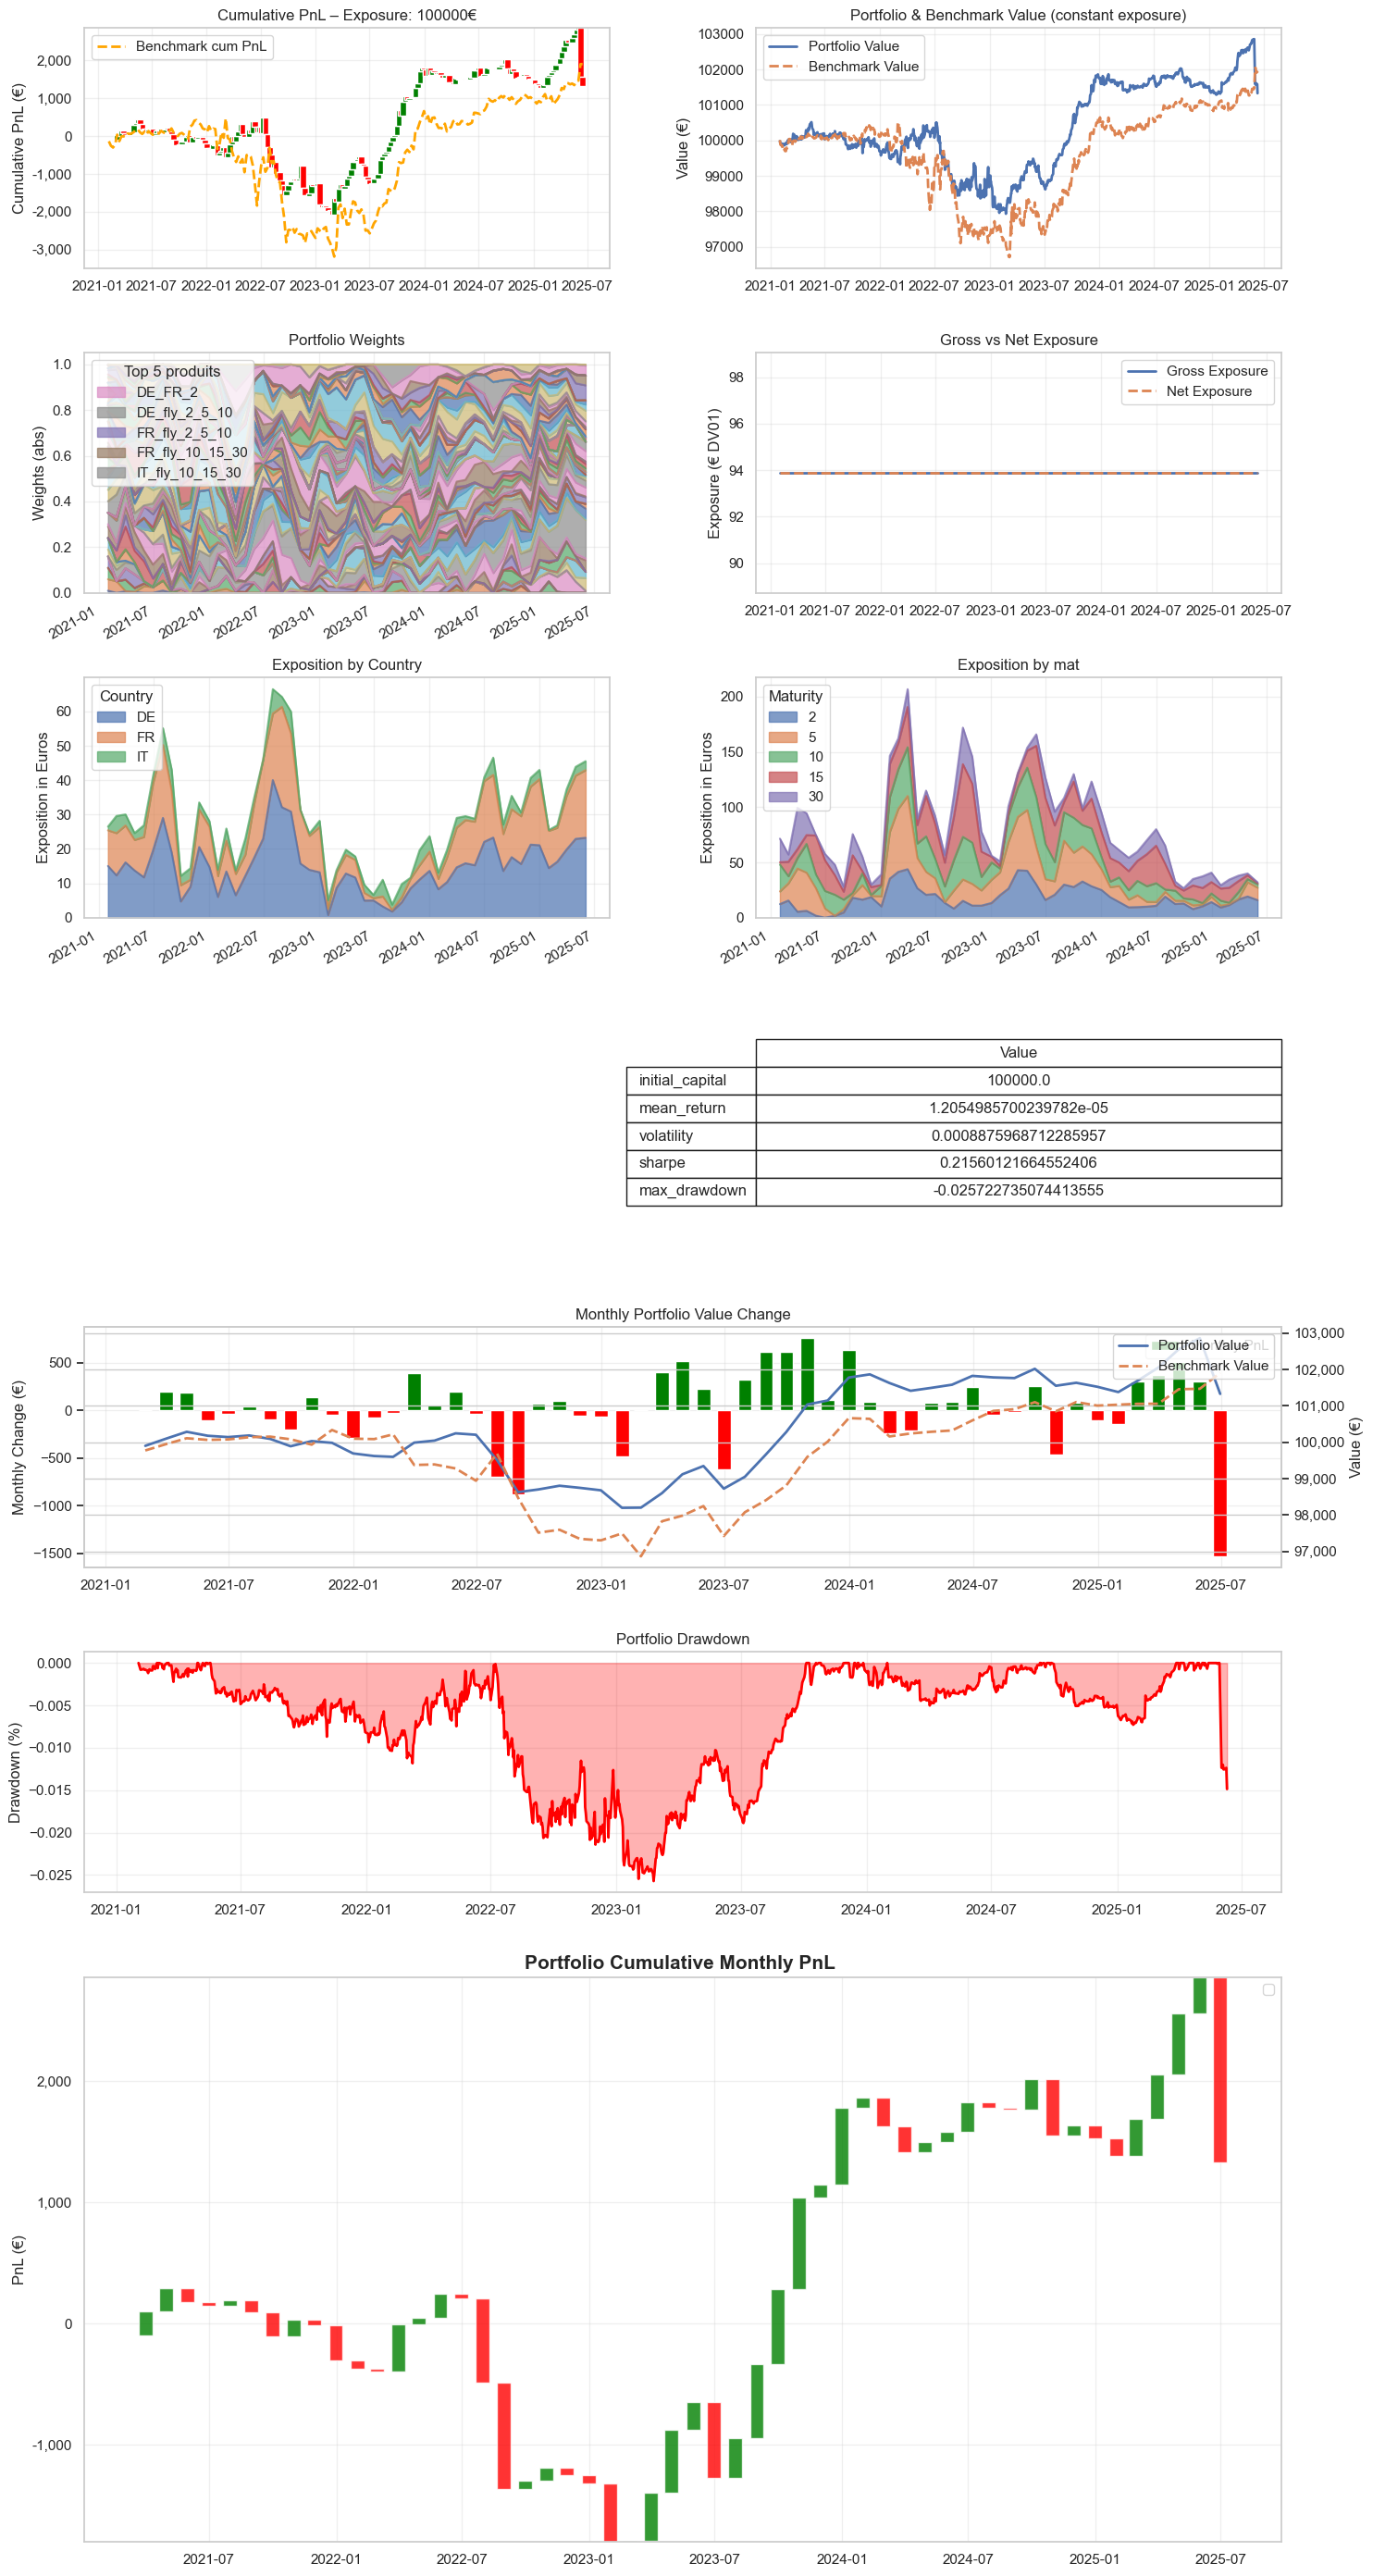

In [47]:
start_date = "2021-01-01"
end_date   = "2025-06-10"


tspf = TimeSeriesPortfolio(
    data=long,
    start_date="2021-01-01",
    end_date="2025-06-10",
    rebalance_freq="1M",
    long_only=True,
    lamb=1,
    benchmark="ew",
    span=3,
    delta=0.05,
    tc_gamma=0.2,   # intensité des coûts dans l’optimisation
    initial_weights= df_weights["weight"]
)
tspf.dv01_by_product = dv01_by_product


tspf.generate_portfolios()

viz = PortfolioDashboardVisualizer(tspf)
viz.plot_dashboard()

In [34]:
tspf.metrics["portfolio_pnl"].sum()
tspf.metrics["transaction_costs"].sum()
tspf.metrics["net_exposure"].describe()


count    5.300000e+01
mean     1.008782e-04
std      1.175236e-03
min     -4.131615e-03
25%     -6.128431e-14
50%      2.775558e-16
75%      1.370015e-13
max      4.479637e-03
dtype: float64

In [35]:
data["price"].describe()
data["dv01"].describe()

# dur approx si dv01 est par 1bp sur prix en base 1
dur_if_price1 = data["dv01"] / (1.0 * 1e-4)

# dur approx si dv01 est par 1bp sur prix en base 100
dur_if_price100 = data["dv01"] / (data["price"] * 1e-4)

dur_if_price1.describe(), dur_if_price100.describe()


(count    23205.000000
 mean        10.495770
 std          7.648902
 min          0.917638
 25%          4.692608
 50%          9.388115
 75%         14.548553
 max         37.338956
 Name: dv01, dtype: float64,
 count    23205.000000
 mean         0.108016
 std          0.076910
 min          0.009122
 25%          0.046786
 50%          0.096283
 75%          0.139630
 max          0.313009
 dtype: float64)

In [36]:
data["pnl_carry"].describe()
data.groupby("country_iso")["pnl_carry"].mean().sort_values()
data["carry_bp_equiv"].describe()


count    23206.000000
mean         0.050541
std          0.626321
min        -18.674996
25%          0.000000
50%          0.028125
75%          0.086134
max          2.138746
Name: carry_bp_equiv, dtype: float64

In [37]:
tspf.metrics["transaction_costs"].describe()
tspf.metrics["transaction_costs"].sum()
tspf.metrics["portfolio_pnl"].sum()


np.float64(116.42347110355854)

In [38]:
# 1) les pires outliers
bad = data.nsmallest(20, "carry_bp_equiv")[[
    "isin","time_stamp","country_iso","mat_cat","coupon_dec","cpn_freq",
    "dv01","pnl_carry","carry_bp_equiv","remaining_maturity"
]]
bad

# 2) est-ce que c’est lié à dv01 trop petit ou maturité très courte ?
data.loc[data["carry_bp_equiv"] < -10, ["dv01","remaining_maturity"]].describe()

# 3) liste des ISIN problématiques
bad_isins = bad["isin"].unique()
bad_isins


array(['IT0005607970', 'DE000BU25018', 'IT0005635583', 'IT0005496770',
       'FR0011883966', 'DE000BU22049', 'IT0005534141', 'IT0005494239',
       'DE000BU22106', 'IT0005584856', 'FR001400QMF9', 'IT0005548315',
       'IT0005611741', 'FR001400AIN5', 'IT0005365165', 'FR0014009O62'],
      dtype=object)

In [39]:
bad_isins = [
    "FR001400FYQ4","IT0005607269","FR001400PM68","FR001400HI98",
    "IT0005566408","IT0005518128","IT0005521981","IT0005584849",
    "IT0005560948","IT0005500068","IT0005611055","DE0001135226",
    "DE000BU22056","IT0005637399","DE000BU2F009","IT0005631590",
    "FR001400OHF4","DE000BU22064","IT0005657330","IT0005582421"
]

meta[meta["isin"].isin(bad_isins)].sort_values("isin")

data.loc[data["isin"].isin(bad_isins)].groupby("isin").agg(
    n=("isin","size"),
    min_ts=("time_stamp","min"),
    max_ts=("time_stamp","max"),
    min_rem=("remaining_maturity","min"),
    min_dv01=("dv01","min"),
    min_carry=("carry_bp_equiv","min"),
)


,n,min_ts,max_ts,min_rem,min_dv01,min_carry
isin,,,,,,


In [40]:
tspf.metrics["portfolio_pnl"].sum()
tspf.metrics["transaction_costs"].sum()
tspf.metrics["portfolio_pnl"].sum() + tspf.metrics["transaction_costs"].sum()


np.float64(2500.5614305524277)

In [41]:
bo["q25_spread_yield"].describe()


count    113.000000
mean       0.010973
std        0.008990
min        0.001000
25%        0.006000
50%        0.009000
75%        0.014000
max        0.060000
Name: q25_spread_yield, dtype: float64

In [42]:
# 1) Échelle dv01 / duration
print("PRICE DESC:")
print(data["price"].describe())
print("\nDV01 DESC:")
print(data["dv01"].describe())

dur_if_price1 = data["dv01"] / (1.0 * 1e-4)
dur_if_price100 = data["dv01"] / (data["price"] * 1e-4)
print("\nDuration approx (price=1):")
print(dur_if_price1.describe())
print("\nDuration approx (price=100):")
print(dur_if_price100.describe())

# 2) Carry global
print("\nCARRY BP EQUIV DESC:")
print(data["carry_bp_equiv"].describe())

# 3) Outliers carry (top 20)
print("\nWorst carry rows:")
print(
    data.nsmallest(20, "carry_bp_equiv")[[
        "isin","time_stamp","country_iso","mat_cat",
        "coupon_dec","cpn_freq","dv01","pnl_carry",
        "carry_bp_equiv","remaining_maturity"
    ]]
)

# 4) Coûts de transaction vs PnL
print("\nPNL vs TC:")
print("Portfolio PnL sum:", float(tspf.metrics["portfolio_pnl"].sum()))
print("Transaction costs sum:", float(tspf.metrics["transaction_costs"].sum()))
print("PNL net:", float(tspf.metrics["portfolio_pnl"].sum() + tspf.metrics["transaction_costs"].sum()))

# 5) Benchmark sanity
print("\nBenchmark stats:")
print(tspf.benchmark_returns.describe())
print("Benchmark PnL sum:", float(tspf.metrics["benchmark_pnl"].sum()))

# 6) Exposition net/gross
print("\nExposure stats:")
print(tspf.metrics["net_exposure"].describe())
print(tspf.metrics["gross_exposure"].describe())

# 7) Moyenne return per dv01
print("\nret_total_per_dv01 mean:", data["ret_total_per_dv01"].mean())


PRICE DESC:
count    23205.000000
mean        98.365618
std         12.328112
min         48.887000
25%         95.766000
50%        100.173000
75%        102.774000
max        146.395000
Name: price, dtype: float64

DV01 DESC:
count    23205.000000
mean         0.001050
std          0.000765
min          0.000092
25%          0.000469
50%          0.000939
75%          0.001455
max          0.003734
Name: dv01, dtype: float64

Duration approx (price=1):
count    23205.000000
mean        10.495770
std          7.648902
min          0.917638
25%          4.692608
50%          9.388115
75%         14.548553
max         37.338956
Name: dv01, dtype: float64

Duration approx (price=100):
count    23205.000000
mean         0.108016
std          0.076910
min          0.009122
25%          0.046786
50%          0.096283
75%          0.139630
max          0.313009
dtype: float64

CARRY BP EQUIV DESC:
count    23206.000000
mean         0.050541
std          0.626321
min        -18.674996
25%    